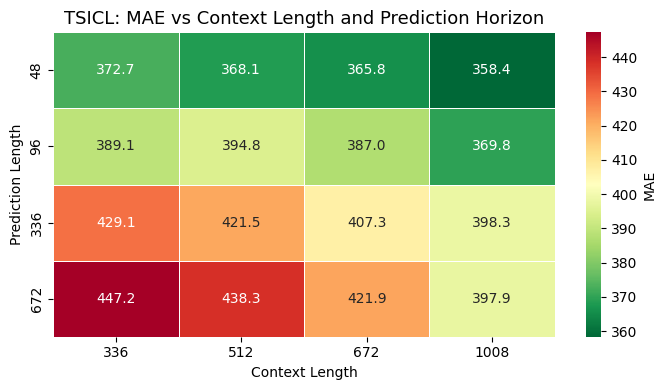

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


# Load your results
df = pd.read_csv("/home/d32485/forecasting_benchmark/outputs/tsicl/cer_bis/multirun/summary_all_runs.csv")

# Select model
model_name = "TSICL"   # change to Chronos-2

model_df = df[df["model"] == model_name]


# Choose metric
metric = "mae"   # change to "crps" or "wql"


# Create pivot table
heatmap_data = (
    model_df
    .pivot(
        index="prediction_length",
        columns="context_length",
        values=metric
    )
    .sort_index()
)


# Plot
plt.figure(figsize=(7, 4))

sns.heatmap(
    heatmap_data,
    annot=True,
    fmt=".1f",
    cmap="RdYlGn_r",
    linewidths=0.5,
    cbar_kws={"label": metric.upper()}
)

plt.title(
    f"{model_name}: {metric.upper()} vs Context Length and Prediction Horizon",
    fontsize=13
)

plt.xlabel("Context Length")
plt.ylabel("Prediction Length")

plt.tight_layout()

plt.savefig(
    f"{model_name}_{metric}_context_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


# ==========================
# Load data
# ==========================
df = pd.read_csv("results.csv")


# ==========================
# Remove duplicate experiments
# ==========================
df_clean = (
    df.drop_duplicates(
        subset=[
            "model",
            "context_length",
            "prediction_length"
        ],
        keep="first"
    )
    .sort_values(
        [
            "model",
            "context_length",
            "prediction_length"
        ]
    )
)


print(
    f"Removed {len(df)-len(df_clean)} duplicate rows"
)


# ==========================
# Plot function
# ==========================
def plot_context_heatmap(
    df,
    model_name,
    metric
):

    model_df = df[
        df["model"] == model_name
    ]

    heatmap_data = (
        model_df
        .pivot(
            index="prediction_length",
            columns="context_length",
            values=metric
        )
        .sort_index()
    )


    plt.figure(
        figsize=(7,4)
    )

    sns.heatmap(
        heatmap_data,
        annot=True,
        fmt=".2f",
        cmap="RdYlGn_r",
        linewidths=0.5,
        cbar_kws={
            "label": metric.upper()
        }
    )


    plt.title(
        f"{model_name} - {metric.upper()} vs Context Length"
    )

    plt.xlabel(
        "Context Length"
    )

    plt.ylabel(
        "Prediction Length"
    )

    plt.tight_layout()


    plt.savefig(
        f"{model_name}_{metric}_context_heatmap.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()



# ==========================
# Generate Chronos2 plots
# ==========================

plot_context_heatmap(
    df_clean,
    "Chronos2",
    "crps"
)


plot_context_heatmap(
    df_clean,
    "Chronos2",
    "mae"
)

ValueError: zero-size array to reduction operation fmin which has no identity

<Figure size 700x400 with 0 Axes>